# Questions Q4-Q5 and Failure Gallery

This notebook covers method redundancy (Q4), contamination-estimation quality (Q5), and a compact failure-oriented view by dataset topology.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from analysis_helpers import (
    ALGORITHM_ORDER,
    annotate_figure,
    load_descriptive_stats,
    save_figure,
    setup_theme,
)

setup_theme()
scores = pd.read_csv("../outputs/phase6_scores.csv.gz")
elbow = pd.read_csv("../outputs/phase6_elbow_validation.csv")
descriptive = load_descriptive_stats().rename(columns={"dataset_id": "dataset"})
scores.shape, elbow.shape

((895710, 6), (28, 6))

,pair,share_tau_gt_0_8
4,IForest vs ECOD,0.107143
2,ECOD vs HBOS,0.071429
3,IForest vs DBSCAN,0.071429
0,DBSCAN vs ECOD,0.035714
1,DBSCAN vs HBOS,0.035714
7,LOF vs DBSCAN,0.035714
8,LOF vs ECOD,0.035714
9,LOF vs HBOS,0.035714
10,OCSVM vs DBSCAN,0.035714
11,OCSVM vs ECOD,0.035714


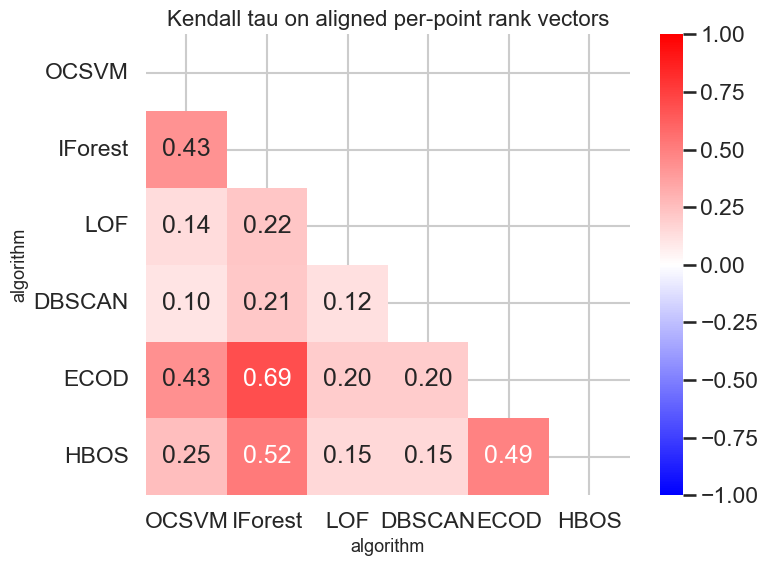

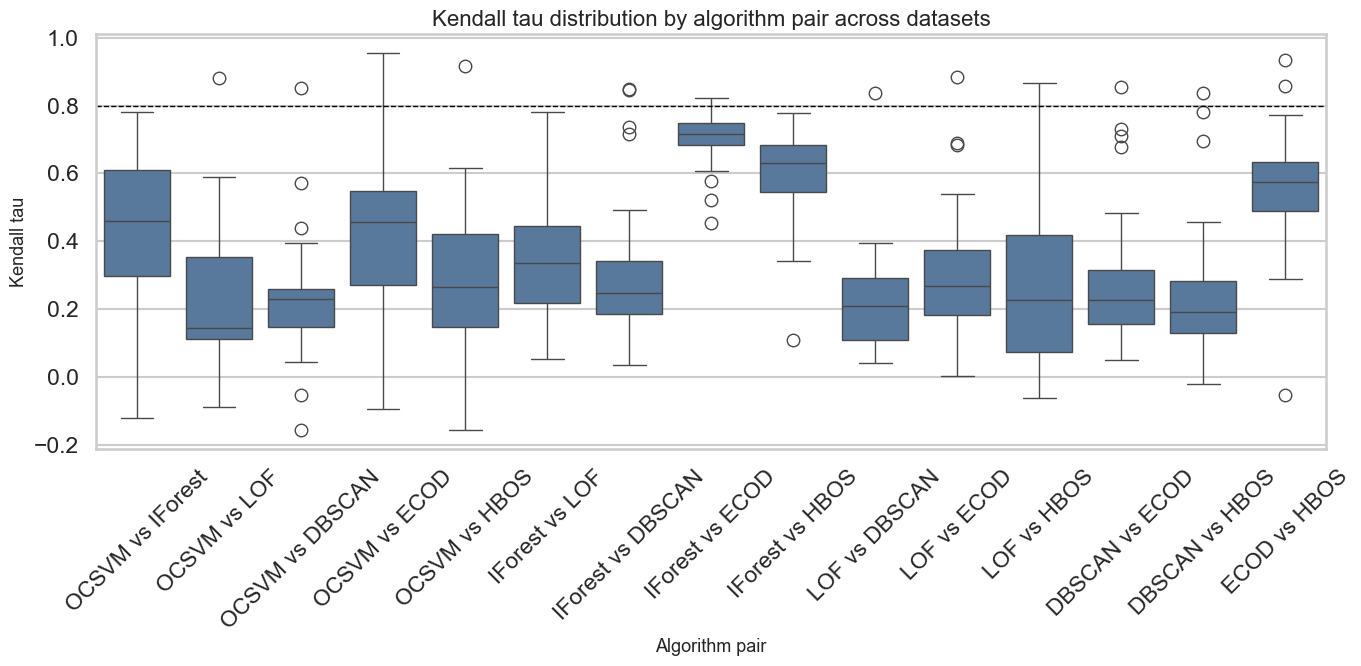

In [2]:
pivoted = scores.pivot(
    index=["dataset", "row_index"], columns="algorithm", values="score_rank"
).dropna()

pair_rows: list[dict[str, float | str]] = []
for dataset, sub in pivoted.groupby(level=0):
    corr = sub.droplevel(0).corr(method="kendall")
    for i, left in enumerate(ALGORITHM_ORDER):
        for right in ALGORITHM_ORDER[i + 1 :]:
            pair_rows.append(
                {
                    "dataset": dataset,
                    "pair": f"{left} vs {right}",
                    "tau": float(corr.loc[left, right]),
                }
            )

pair_tau = pd.DataFrame(pair_rows)
kendall_true = pivoted.corr(method="kendall").reindex(
    index=ALGORITHM_ORDER, columns=ALGORITHM_ORDER
)
mask = np.triu(np.ones_like(kendall_true, dtype=bool), k=1) + np.eye(len(kendall_true), dtype=bool)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    kendall_true,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="bwr",
    center=0.0,
    vmin=-1,
    vmax=1,
    ax=ax,
)
ax.set_title("Kendall tau on aligned per-point rank vectors")
plt.tight_layout()
# annotate_figure(
#     fig,
#     ("Kendall tau from aligned per-point rank scores in "
#      "outputs/phase6_scores.csv.gz; lower triangle shown."),
# )
save_figure("q4_kendall_tau_heatmap.png")

fig, ax = plt.subplots(figsize=(14, 7))
sns.boxplot(data=pair_tau, x="pair", y="tau", ax=ax)
ax.axhline(0.8, linestyle="--", color="black", linewidth=1)
ax.set_title("Kendall tau distribution by algorithm pair across datasets")
ax.set_xlabel("Algorithm pair")
ax.set_ylabel("Kendall tau")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
# annotate_figure(fig, "Each box summarizes per-dataset Kendall tau for one algorithm pair.")
save_figure("q4_pairwise_tau_distribution.png")

redundancy_flags = (
    pair_tau.assign(high_redundancy=lambda d: d["tau"] > 0.8)
    .groupby("pair", as_index=False)["high_redundancy"]
    .mean()
    .rename(columns={"high_redundancy": "share_tau_gt_0_8"})
    .sort_values("share_tau_gt_0_8", ascending=False)
)
redundancy_flags.head(10)

(       dataset  rows_used  features_used  contamination_true  \
 27  ionosphere        351             32            0.358974   
 26     breastw        683              9            0.349927   
 25   satellite       6435             36            0.316395   
 24        pima        768              8            0.348958   
 19       mnist       7603            100            0.092069   
 18  annthyroid       7200              6            0.074167   
 17     shuttle      20000              9            0.071500   
 16      cardio       1831             21            0.096122   
 13      vowels       1456             12            0.034341   
 12  arrhythmia        452            802            0.146018   
 
     contamination_elbow  abs_error  n_features  distance_concentration_ratio  \
 27             0.025641   0.333333          32                      1.964553   
 26             0.021962   0.327965           9                      2.280981   
 25             0.029526   0.286869     

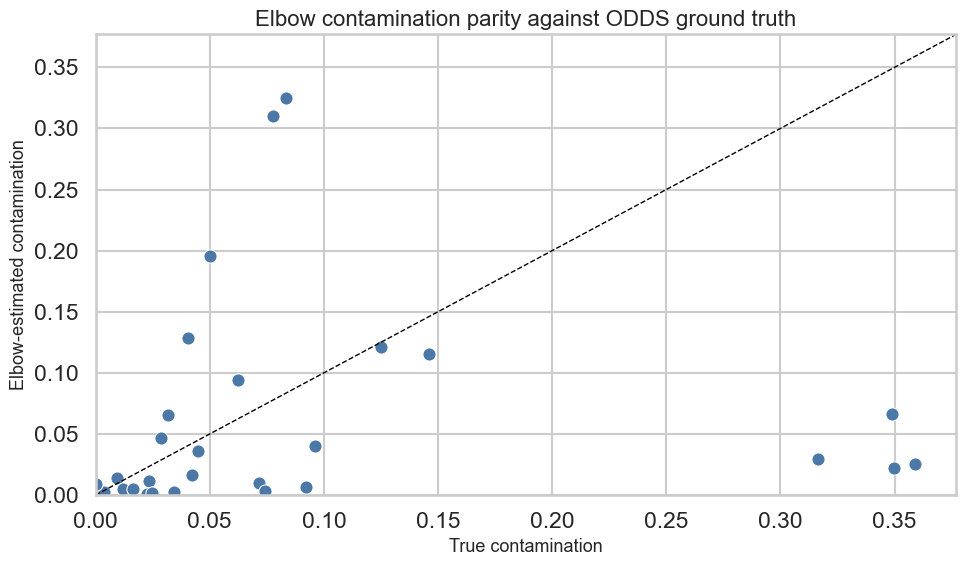

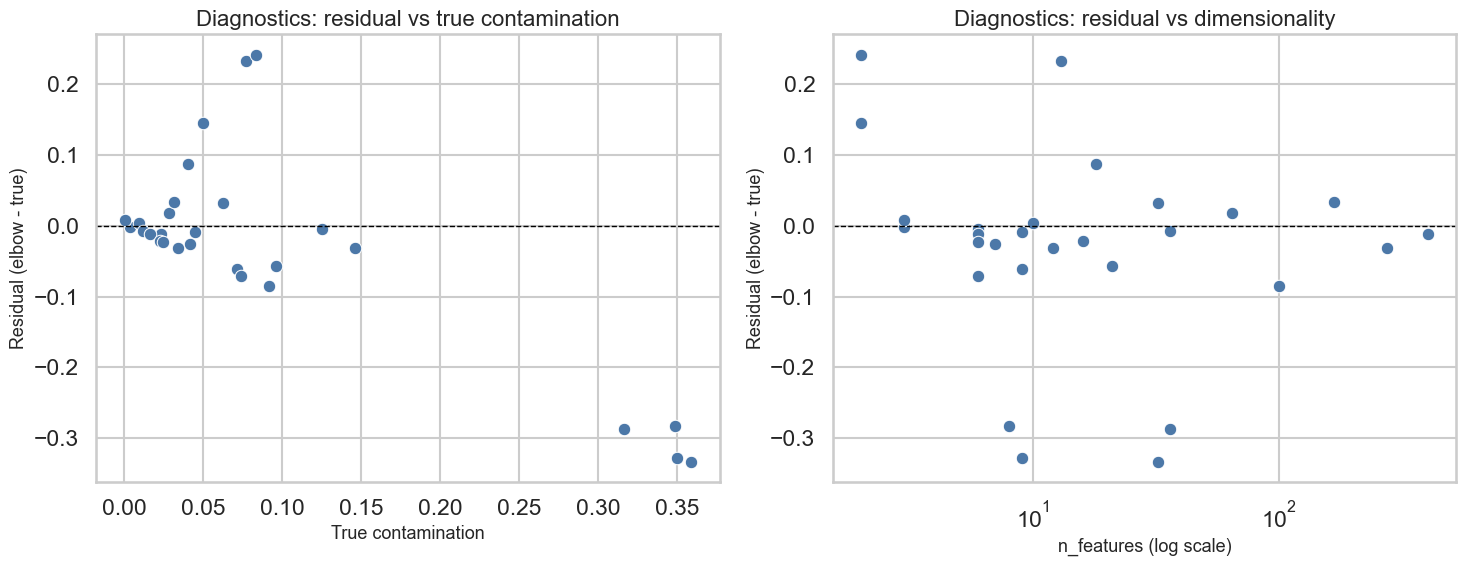

In [3]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=elbow, x="contamination_true", y="contamination_elbow", s=90, ax=ax)
lims = [
    0.0,
    max(elbow[["contamination_true", "contamination_elbow"]].to_numpy().max() * 1.05, 0.05),
]
ax.plot(lims, lims, linestyle="--", color="black", linewidth=1)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_title("Elbow contamination parity against ODDS ground truth")
ax.set_xlabel("True contamination")
ax.set_ylabel("Elbow-estimated contamination")
plt.tight_layout()
# annotate_figure(
#     fig,
#     ("Parity between true contamination and elbow estimate from "
#      "outputs/phase6_elbow_validation.csv."),
# )
save_figure("q5_elbow_parity.png")

elbow_diag = elbow.merge(
    descriptive[["dataset", "n_features", "distance_concentration_ratio"]],
    on="dataset",
    how="left",
)
elbow_diag["residual"] = elbow_diag["contamination_elbow"] - elbow_diag["contamination_true"]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.scatterplot(data=elbow_diag, x="contamination_true", y="residual", ax=axes[0])
axes[0].axhline(0.0, linestyle="--", color="black", linewidth=1)
axes[0].set_title("Diagnostics: residual vs true contamination")
axes[0].set_xlabel("True contamination")
axes[0].set_ylabel("Residual (elbow - true)")

sns.scatterplot(data=elbow_diag, x="n_features", y="residual", ax=axes[1])
axes[1].axhline(0.0, linestyle="--", color="black", linewidth=1)
axes[1].set_xscale("log")
axes[1].set_title("Diagnostics: residual vs dimensionality")
axes[1].set_xlabel("n_features (log scale)")
axes[1].set_ylabel("Residual (elbow - true)")

plt.tight_layout()
# annotate_figure(
#     fig,
#     ("Residual = elbow estimate minus true contamination; diagnostics "
#      "across contamination and dimensionality."),
# )
save_figure("q5_elbow_residual_diagnostics.png")

(
    elbow_diag.sort_values("residual").head(10),
    elbow_diag.sort_values("residual", ascending=False).head(10),
)

,dataset,winner,winner_score,contamination,n_features
7,ionosphere,DBSCAN,0.501425,0.358974,32
2,breastw,DBSCAN,0.500732,0.349927,9
15,pima,DBSCAN,0.500651,0.348958,8
16,satellite,DBSCAN,0.500078,0.316395,36
1,arrhythmia,DBSCAN,0.501106,0.146018,274
22,vertebral,DBSCAN,0.502083,0.125000,6
3,cardio,DBSCAN,0.500273,0.096122,21
11,mnist,DBSCAN,0.500066,0.092069,100
26,wut/x2,DBSCAN,0.504167,0.083333,2
25,wine,DBSCAN,0.503876,0.077519,13


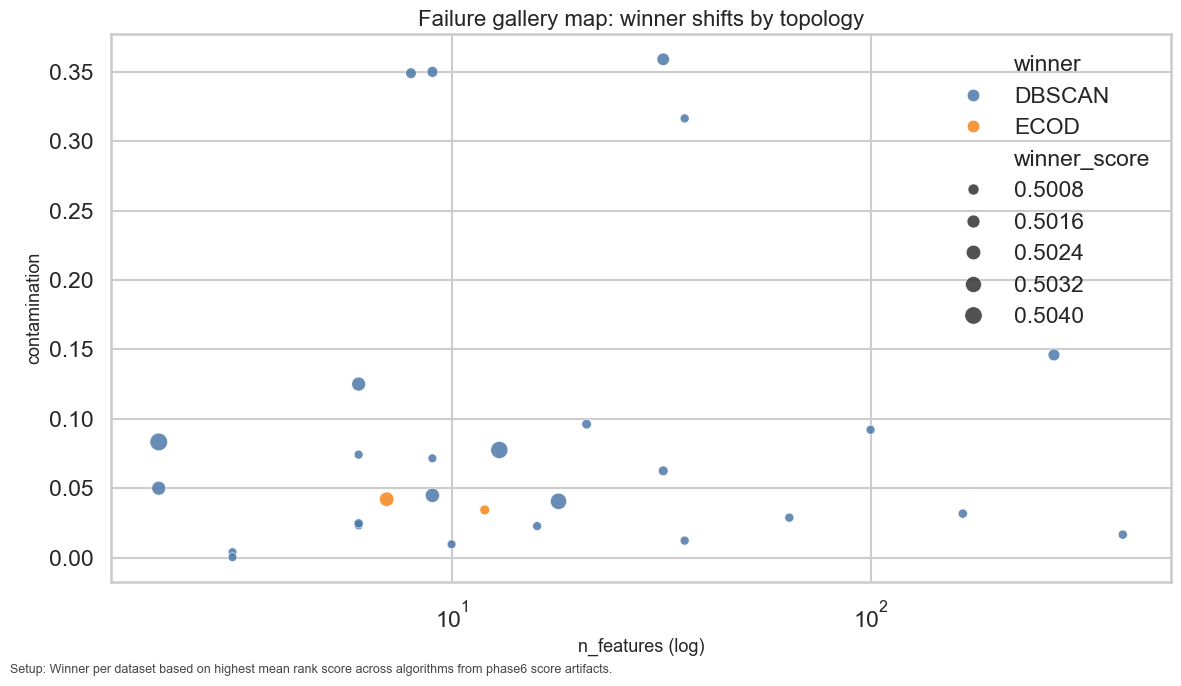

In [4]:
summary = (
    scores.groupby(["dataset", "algorithm"], as_index=False)["score_rank"]
    .mean()
    .rename(columns={"score_rank": "mean_rank"})
)
wide = summary.pivot(index="dataset", columns="algorithm", values="mean_rank").reset_index()
fail = descriptive[
    ["dataset", "contamination", "n_features", "distance_concentration_ratio"]
].merge(wide, on="dataset", how="inner")

winners = summary.loc[
    summary.groupby("dataset")["mean_rank"].idxmax(), ["dataset", "algorithm", "mean_rank"]
]
winners = winners.rename(columns={"algorithm": "winner", "mean_rank": "winner_score"})
fail = fail.merge(winners, on="dataset", how="left")

fig, ax = plt.subplots(figsize=(12, 7))
sns.scatterplot(
    data=fail,
    x="n_features",
    y="contamination",
    hue="winner",
    size="winner_score",
    alpha=0.85,
    ax=ax,
)
ax.set_xscale("log")
ax.set_title("Failure gallery map: winner shifts by topology")
ax.set_xlabel("n_features (log)")
ax.set_ylabel("contamination")
plt.tight_layout()
annotate_figure(
    fig,
    (
        "Winner per dataset based on highest mean rank score across "
        "algorithms from phase6 score artifacts."
    ),
)
save_figure("q4_q5_failure_gallery_winner_map.png")

fail[["dataset", "winner", "winner_score", "contamination", "n_features"]].sort_values(
    ["contamination", "n_features"], ascending=[False, False]
).head(15)